In [1]:
import os
import sam3
import torch
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sam3.florence2_utils import region_proposal
from sam3.model_builder import build_sam3_multiplex_video_predictor
import glob
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sam3.visualization_utils import (
    load_frame,
    prepare_masks_for_visualization,
    visualize_formatted_frame_output,
    show_box,
    show_mask,
)

plt.rcParams["axes.titlesize"] = 12
plt.rcParams["figure.titlesize"] = 12
sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")

def propagate_in_video(predictor, session_id):
    outputs_per_frame = {}
    for response in predictor.handle_stream_request(
        request=dict(
            type="propagate_in_video",
            session_id=session_id,
        )
    ):
        outputs_per_frame[response["frame_index"]] = response["outputs"]

    return outputs_per_frame


def abs_to_rel_coords(coords, IMG_WIDTH, IMG_HEIGHT, coord_type="point"):
    """Convert absolute coordinates to relative coordinates (0-1 range)

    Args:
        coords: List of coordinates
        coord_type: 'point' for [x, y] or 'box' for [x, y, w, h]
    """
    if coord_type == "point":
        return [[x / IMG_WIDTH, y / IMG_HEIGHT] for x, y in coords]
    elif coord_type == "box":
        return [
            [x / IMG_WIDTH, y / IMG_HEIGHT, w / IMG_WIDTH, h / IMG_HEIGHT]
            for x, y, w, h in coords
        ]
    else:
        raise ValueError(f"Unknown coord_type: {coord_type}")

def plot_bbox(image, data):
    fig, ax = plt.subplots()

    # Display the image
    ax.imshow(image)

    # Plot each bounding box
    for bbox, label in zip(data['bboxes'], data['labels']):
        # Unpack the bounding box coordinates
        x1, y1, x2, y2 = bbox
        # Create a Rectangle patch
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1, edgecolor='r', facecolor='none')
        # Add the rectangle to the Axes
        ax.add_patch(rect)
        # Annotate the label
        plt.text(x1, y1, label, color='white', fontsize=8, bbox=dict(facecolor='red', alpha=0.5))

    # Remove the axis ticks and labels
    ax.axis('off')

    # Show the plot
    plt.show()

video_path = f"{sam3_root}/assets/videos/0001"

/cluster/scratch/niacobone/sam3/myenv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


/cluster/scratch/niacobone/sam3/myenv/lib/python3.12/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large:
- configuration_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large:
- modeling_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large:
- processing_florence2.py
. Make sure to double-check they do not contain any added ma

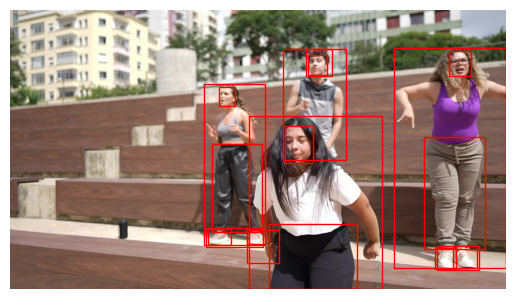

Image dimensions: 1280x720


In [4]:
first_frame_path = sorted(glob.glob(os.path.join(video_path, "*.jpg")))[0]
image = Image.open(first_frame_path)

result = region_proposal(image)

plot_bbox(image, result)

# Store image dimensions for coordinate conversion
img_array = np.array(image)
IMG_HEIGHT, IMG_WIDTH = img_array.shape[:2]
print(f"Image dimensions: {IMG_WIDTH}x{IMG_HEIGHT}")

In [5]:
predictor = build_sam3_multiplex_video_predictor()

response = predictor.handle_request(
    request=dict(
        type="start_session",
        resource_path=video_path,
    )
)
session_id = response["session_id"]

_ = predictor.handle_request(
    request=dict(
        type="reset_session",
        session_id=session_id,
    )
)

dynamic_multimask_via_stability is reset to False in the multiplex model


INFO 2026-05-22 12:12:29,470 1469375 sam3_multiplex_base.py: 336: `setting max_num_objects` to 16 -- creating num_obj_for_compile=1 objects for torch.compile cache


Missing keys (64): ['detector.backbone.vision_backbone.trunk.blocks.0.attn.freqs_cis_real', 'detector.backbone.vision_backbone.trunk.blocks.0.attn.freqs_cis_imag', 'detector.backbone.vision_backbone.trunk.blocks.1.attn.freqs_cis_real', 'detector.backbone.vision_backbone.trunk.blocks.1.attn.freqs_cis_imag', 'detector.backbone.vision_backbone.trunk.blocks.2.attn.freqs_cis_real', 'detector.backbone.vision_backbone.trunk.blocks.2.attn.freqs_cis_imag', 'detector.backbone.vision_backbone.trunk.blocks.3.attn.freqs_cis_real', 'detector.backbone.vision_backbone.trunk.blocks.3.attn.freqs_cis_imag', 'detector.backbone.vision_backbone.trunk.blocks.4.attn.freqs_cis_real', 'detector.backbone.vision_backbone.trunk.blocks.4.attn.freqs_cis_imag']...


frame loading (image folder) [rank=0]:   2%|▏         | 5/270 [00:00<00:52,  5.09it/s]

In [ ]:
# Segment objects using box prompts from region proposal
# Bboxes are already in SAM format [xmin, ymin, width, height] normalized (0-1)
bboxes_rel = np.array(result['bboxes'], dtype=np.float32)
print(f"Adding {len(bboxes_rel)} objects with box prompts")

# Add box prompts for each detected object
frame_idx = 0  # Start from first frame
for obj_idx, (bbox_rel, label) in enumerate(zip(bboxes_rel, result['labels'])):
    obj_id = obj_idx + 1  # Use 1-based object IDs
    
    # Convert to tensor and reshape for add_prompt
    box_tensor = torch.tensor([bbox_rel], dtype=torch.float32)
    
    # Add box prompt using the correct API
    response = predictor.handle_request(
        request=dict(
            type="add_prompt",
            session_id=session_id,
            frame_index=frame_idx,
            obj_id=obj_id,
            bounding_boxes=box_tensor.tolist(),
            bounding_box_labels=[1],
        )
    )
    
    print(f"Added object {obj_id}: {label} with bbox {bbox_rel}")

In [ ]:
# Propagate segmentation through the entire video
print("Propagating segmentation through video...")
video_segments = propagate_in_video(predictor, session_id)
print(f"Segmentation complete for {len(video_segments)} frames")

# Load all frames for visualization
frame_files = sorted(glob.glob(os.path.join(video_path, "frames", "*.jpg")))
video_frames_for_vis = [cv2.cvtColor(cv2.imread(f), cv2.COLOR_BGR2RGB) for f in frame_files]

# Visualize results every N frames
vis_stride = max(1, len(video_frames_for_vis) // 10)  # Show ~10 frames
print(f"Visualizing every {vis_stride} frames")

for frame_idx in range(0, len(video_frames_for_vis), vis_stride):
    if frame_idx not in video_segments:
        continue
    
    frame = video_frames_for_vis[frame_idx]
    outputs = video_segments[frame_idx]
    
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.imshow(frame)
    ax.set_title(f"Frame {frame_idx}")
    ax.axis('off')
    
    # Draw segmentation masks for each object
    if outputs and 'masks' in outputs:
        masks = outputs['masks']
        for obj_id, mask in enumerate(masks, 1):
            from sam3.visualization_utils import show_mask
            show_mask((mask > 0.0).cpu().numpy() if hasattr(mask, 'cpu') else (mask > 0.0), 
                     ax, obj_id=obj_id)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Visualize the first frame with bboxes and segmentation masks
from sam3.visualization_utils import show_box, show_mask

first_frame = video_frames_for_vis[0]
first_frame_outputs = video_segments[0]

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(first_frame)
ax.set_title("First Frame: Region Proposal Bboxes + SAM3 Segmentation")
ax.axis('off')

# Draw bounding boxes
for bbox_abs, label in zip(result['bboxes'], result['labels']):
    show_box(bbox_abs, ax)

# Draw segmentation masks
if first_frame_outputs and 'masks' in first_frame_outputs:
    masks = first_frame_outputs['masks']
    for obj_id, mask in enumerate(masks, 1):
        show_mask((mask > 0.0).cpu().numpy() if hasattr(mask, 'cpu') else (mask > 0.0), 
                 ax, obj_id=obj_id)

plt.tight_layout()
plt.show()

print(f"Total objects segmented: {len(bboxes_rel)}")